<a href="https://colab.research.google.com/github/rodrigai/Alex-s-NEUR-265-Repository/blob/main/coding_Homework_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

######Alex Rodriguez

*NEUR 265- Introduction to Neural Data Analysis*

Extension Granted- **4/17/2026**

In [22]:
#Imports relevant modules

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

%whos

Variable                  Type                 Data/Info
--------------------------------------------------------
ECDF                      type                 <class 'statsmodels.distr<...>rical_distribution.ECDF'>
Poisson                   type                 <class 'statsmodels.genmo<...>families.family.Poisson'>
ax                        ndarray              2: 2 elems, type `object`, 16 bytes
b1                        Series               Intercept     -1.346329\n<...> 0.411876\ndtype: float64
chi2                      chi2_gen             <scipy.stats._continuous_<...>object at 0x79b049ce3770>
conditioning_traces       ndarray              10458x63: 658854 elems, type `float64`, 5270832 bytes (5.0266571044921875 Mb)
df                        type                 <class 'pandas.core.frame.DataFrame'>
extinction_predictors     ndarray              14211: 14211 elems, type `float64`, 113688 bytes (111.0234375 kb)
extinction_predictors1    ndarray              14209: 14209 elems, t

In [23]:
#Imports files as numpy arrays

url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
fear_traces = np.loadtxt(url, delimiter = ',')

url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
extinction_predictors = np.loadtxt(url2, delimiter = ',')

shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',').astype(int)

tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',').astype(int)

In [24]:
#Makes conditioning and extinction trace variables, where conditioning is the first 10458 samples as rows with ROI as columns and extinction is the remaining 10459 rows through the final sample with ROIas

print(fear_traces.shape)

conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10459:, :]

(24668, 63)


In [25]:
#Prints sizes of conditioning and extinction trace arrays

print(conditioning_traces.size)
print(extinction_traces.size)

658854
895167


In [26]:
#Makes time variables for conditioning and time, which start at 0, end at the total length of the recording session, and have a legnth equal to the number of samples for each session

total_time_c = (conditioning_traces.shape[0])/15
#in units of seconds

time_conditioning = np.linspace(0, total_time_c, conditioning_traces.shape[0])

total_time_e = (extinction_traces.shape[0])/15

time_extinction = np.linspace(0, total_time_e, extinction_traces.shape[0])

In [27]:
#Finds total length of time in seconds for each variable to answer next question

print(time_conditioning[-1])
print(time_extinction[-1])

697.2
947.2666666666667


63 ROIs were imaged during these sessions. The conditioning session had lasted a total of 697.2 seconds or 11.62 minutes. The extinction session had lasted a total of 947.2666666666667 seconds or 15.787777777777778 minutes.

In [28]:
#Prints shock and tone values for next part

print(shock_index)
print(tone_index)

[358 448 538]
[330 420 510]


Text(0, 0.5, 'ROIs')

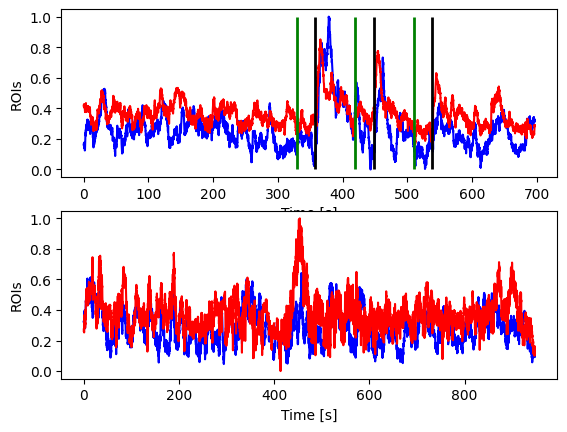

In [29]:
#Plots 1st and 2nd ROIs of conditioning and extriction variables in different subplots. Black vertical lines are shock onset while green are tone onset

fig, ax = plt.subplots(2,1)
ax[0].plot(time_conditioning, conditioning_traces[:, 0], color = 'blue')
ax[0].plot(time_conditioning, conditioning_traces[:, 1], color = 'red')
ax[0].vlines(358, 0, 1, 'k', lw=2, color = 'black')
ax[0].vlines(448, 0, 1, 'k', lw=2, color = 'black')
ax[0].vlines(538, 0, 1, 'k', lw=2, color = 'black')
ax[0].vlines(330, 0, 1, 'k', lw=2, color = 'green')
ax[0].vlines(420, 0, 1, 'k', lw=2, color = 'green')
ax[0].vlines(510, 0, 1, 'k', lw=2, color = 'green')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('ROIs')

ax[1].plot(time_extinction, extinction_traces[:, 0], color = 'blue')
ax[1].plot(time_extinction, extinction_traces[:, 1], color = 'red')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('ROIs')


When conditioning activity increases, extinction activity also increases across both ROIs, causing me to think there is a relationship between the two. However, extinction generally has more waves than conditioning.

In [30]:
#Reuses code from 4/02 notebook to recreate shock/tone arrays and predictors_conditioning variable

shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

predictors_conditioning = conditioning_traces[:,0]

predictors = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
model1 = sm.GLM(predictors_conditioning, predictors, family=Poisson())
model1_results = model1.fit() # Fit model to our data
b1 = model1_results.params
print('b1:')
print(b1)

predictors['shock onset'] = shock_array
model3 = sm.GLM(predictors_conditioning, predictors, family=Poisson())
model3_results = model3.fit() # Fit model to our data
b1 = model3_results.params
print('b1:')
print(b1)

b1:
Intercept    -1.272916
tone onset   -0.328708
dtype: float64
b1:
Intercept     -1.346329
tone onset    -0.431768
shock onset    0.411876
dtype: float64


In [31]:
#Create r_model_conditioning variable and run a for loop that etracts an ROI from conditioning_traces, runs an sm.GLM between the trace and the predictors variable created, fits the model, creates a predicted trace, gets a correlation coefficent using pearsonr, and stores the correlation coefficent in a new column of r_index_conditioning

r_model_conditioning = np.zeros(63)

for i in range(63):
  trace_temp = conditioning_traces[:,i]
  model3 = sm.GLM(trace_temp, predictors, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_conditioning[i] = r3.statistic
  r_index_conditioning = r_model_conditioning

In [32]:
#Create r_model_conditioning variable and run a for loop that etracts an ROI from extinction_traces, runs an sm.GLM between the trace and the predictors variable created, fits the model, creates a predicted trace, gets a correlation coefficent using pearsonr, and stores the correlation coefficent in a new column of r_index_conditioning

extinction_predictors1 = extinction_predictors[:14209]

r_model_conditioning = np.zeros(63)

for i in range(63):
  trace_temp1 = extinction_traces[:,i]
  model1 = sm.GLM(trace_temp1, extinction_predictors1, family=Poisson())
  model1_results = model1.fit()
  predicted_trace = model1_results.predict()
  r1 = pearsonr(trace_temp1, predicted_trace)
  r_model_conditioning[i] = r1.statistic
  r_index_extinction = r_model_conditioning

In [33]:
#Uses pearsonr function to correlate r_index_conditioning and r_index extinction variables

result = pearsonr(r_index_conditioning, r_index_extinction)
print(result)

PearsonRResult(statistic=np.float64(0.015246809836773187), pvalue=np.float64(0.905591254227619))


Text(0, 0.5, 'Extinction')

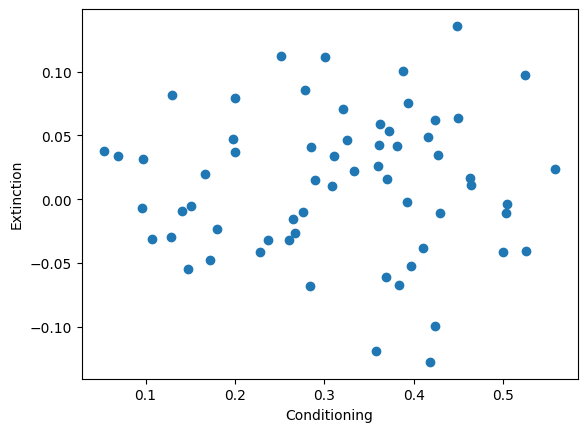

In [35]:
#Makes a scatter plot with r_index_conditioning on the x-axis, r_index_extinction on the y-axis, and labels axes

plt.scatter(r_index_conditioning, r_index_extinction)
plt.xlabel('Conditioning')
plt.ylabel('Extinction')

Based on my correlation coefficent and scatter plot, it does not seem that a cell responding strongly to shock and tone onset during the conditioning session is more likely to respond strongly to tone onset during the extinction session.